# **Atmospheric Sensitivity to Solar Forcing Mini-project using SpeedyWeather.jl**

**Understanding how solar variability impacts climate is an important part of Sun–Earth connection research.**

In [2]:
using Pkg
Pkg.add("IJulia")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [3]:
Pkg.add("SpeedyWeather")
Pkg.add("GeoMakie")
Pkg.add("CairoMakie")
Pkg.add("NCDatasets")

#GeoMakie.jl is a Julia package for plotting geospatial data on a given map projection. It is built on top of the Makie.jl plotting ecosystem.
#CairoMakie uses Cairo.jl to draw vector graphics to SVG and PDF. Use it to achieve the highest-quality plots for publications.

   Resolving package versions...
   Installed LowerTriangularArrays ───────── v0.1.2
   Installed aws_c_auth_jll ──────────────── v0.9.6+0
   Installed LRUCache ────────────────────── v1.6.2
   Installed FastGaussQuadrature ─────────── v1.1.0
   Installed FFTW ────────────────────────── v1.10.0
   Installed AssociatedLegendrePolynomials ─ v1.0.2
   Installed ModelParameters ─────────────── v0.4.6
   Installed DomainSets ──────────────────── v0.7.18
   Installed IntelOpenMP_jll ─────────────── v2025.2.0+0
   Installed aws_c_sdkutils_jll ──────────── v0.2.4+1
   Installed aws_c_cal_jll ───────────────── v0.9.13+0
   Installed RingGrids ───────────────────── v0.1.3
   Installed SpeedyTransforms ────────────── v0.1.1
   Installed CFTime ──────────────────────── v0.2.8
   Installed MPIABI_jll ──────────────────── v0.1.3+0
   Installed JLD2 ────────────────────────── v0.6.4
   Installed MicrosoftMPI_jll ────────────── v10.1.4+3
   Installed GPUArrays ───────────────────── v11.4.1
   Installe

In [4]:
# Check set up

using SpeedyWeather
using GeoMakie, CairoMakie
using Statistics

# **1. Baseline Atmospheric Temperature Distribution**

**Global near-surface temperature under standard solar forcing (control simulation)**

 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:01:35 (2000-04-10, 248.53 years/day, 94 m/s, [-75, 33] ˚C)


Simulation complete!
Temperature size: (3168,)
Mean temperature: 280.31744


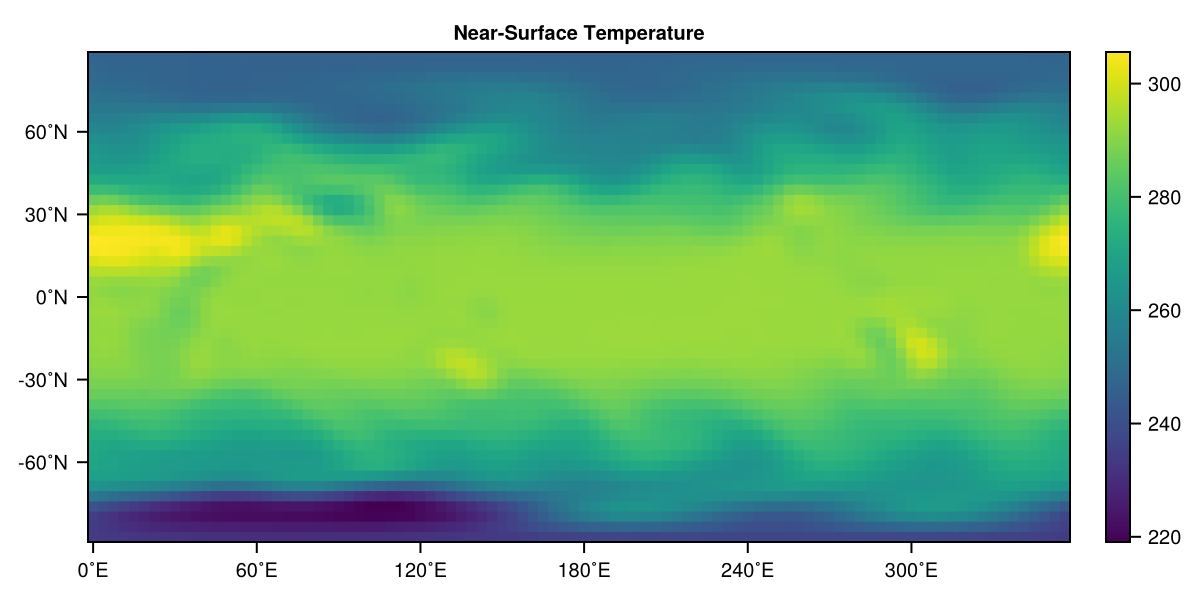

In [9]:
using Statistics

# spectral_grid = SpectralGrid(trunc=31, nlayers=8)
spectral_grid = SpectralGrid()
model = PrimitiveWetModel(spectral_grid)
sim = initialize!(model)

run!(sim, period=Day(100))

println("Simulation complete!")


# variable
T = sim.diagnostic_variables.grid.temp_grid[:,end]

println("Temperature size: ", size(T))
println("Mean temperature: ", mean(T))

# Plot lowest atmospheric level

heatmap(
    # T[:,:,end],
    T,
    title="Near-Surface Temperature"
    #xlabel="Longitude",
    #ylabel="Latitude",
    #colorbar_title="T (K)"
)

The plotted figure represents the near-surface atmospheric temperature field produced by a global circulation simulation using SpeedyWeather.jl. The horizontal (x) axis corresponds to the Earth's longitude, while the vertical (y) axis corresponds to the Earth's latitude, representing positions from the South Pole to the North Pole. The temperature values shown in the color scale are expressed in Kelvin (K), with the simulated mean value (~280 K) which is physically reasonable for a global atmospheric average that includes colder high-latitude and upper-layer influences.

Each pixel in the heatmap represents the temperature at a specific grid point on Earth's surface layer, effectively providing a spatial snapshot of the atmospheric state after 100 days of model evolution. The large-scale structure in the plot is primarily governed by solar radiative forcing, where incoming solar energy is unevenly distributed due to Earth's curvature: regions near the equator receive more direct sunlight and thus exhibit higher temperatures, while higher latitudes receive less sunlight per unit area, resulting in cooler temperatures. This fundamental balance between incoming solar radiation and outgoing terrestrial radiation can be described by the radiative equilibrium relation:

$$(1−𝛼)\frac{S}{4}= 𝜎𝑇^{4} ,$$

where S is the solar constant, $\alpha$ is planetary albedo, and $\sigma$ is the Stefan-Boltzmann constant.

However, the temperature distribution is not perfectly zonally symmetric, indicating that the model is not purely radiative but also includes atmospheric dynamics such as fluid motion, heat transport, and instabilities. These processes redistribute energy through winds and circulation patterns, producing spatial variability beyond simple equator-to-pole gradients.

Overall, this baseline simulation represents a dynamically consistent climate state arising from the interaction of radiation, thermodynamics, and fluid dynamics. It serves as a reference configuration for investigating atmospheric sensitivity to solar forcing, where small perturbations in solar irradiance can be introduced to examine how the temperature field and more broadly, atmospheric circulation-responds.

# **2. Temperature Response to Solar Forcing (ΔT)**

**Spatial distribution of temperature change resulting from increased solar irradiance**

**Solar forcing is introduced by modifying the solar constant in the planetary configuration, which alters the incoming shortwave radiation in the model's radiative transfer scheme, thereby changing the atmospheric energy balance and driving temperature responses.**

-- Small perturbations (0.1 - 0.2%) in solar forcing allow the system to remain within a quasi-linear regime, where the temperature response scales proportionally with the forcing. Larger perturbations push the system into a nonlinear regime, where feedback processes dominate and the model may become unstable or physically unrealistic.

 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:05:08 (2000-12-31, 280.37 years/day, 82 m/s, [-78, 27] ˚C)
 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:05:04 (2000-12-31, 283.74 years/day, 79 m/s, [-76, 26] ˚C)


Solar forcing simulation complete!
Max ΔT: 27.672287
Min ΔT: -14.341537
Mean ΔT: 0.10791978


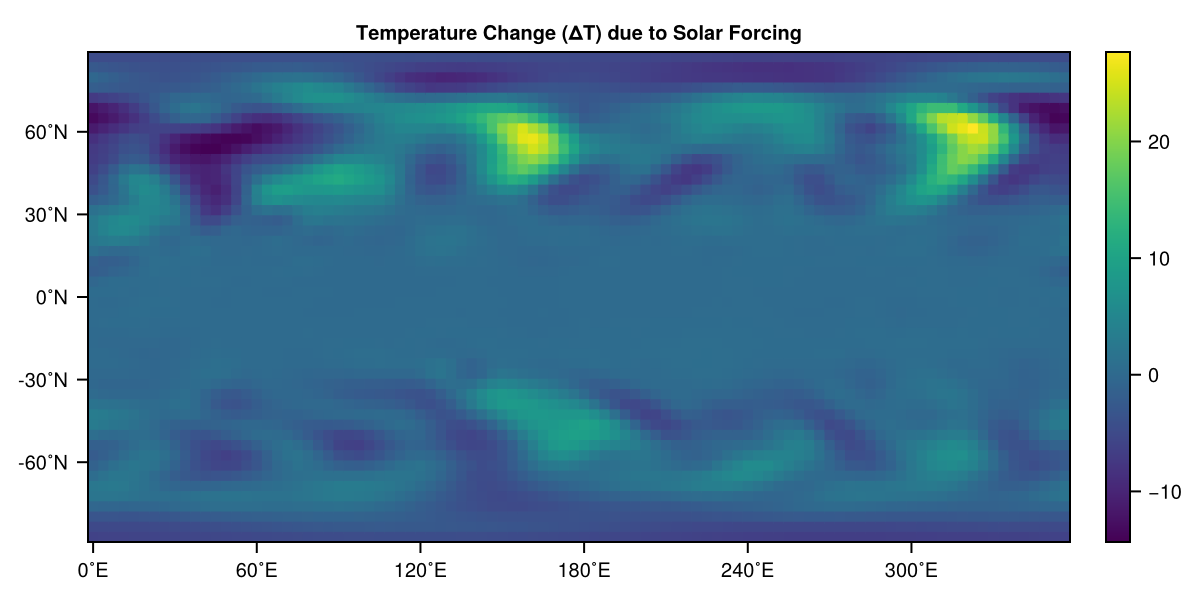

In [17]:
# Period = 365 days
# Solar Forcing = 0.1%


spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(365))   #change to 365 days
#T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]
T1 = sim1.diagnostic_variables.grid.temp_grid[:,end]
T1_mean = mean(sim1.diagnostic_variables.grid.temp_grid, dims=3)

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(365))   #change to 365 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,end]
T2_mean = mean(sim2.diagnostic_variables.grid.temp_grid, dims=3)

println("Solar forcing simulation complete!")

ΔT = T2 - T1
ΔT_mean = T2_mean - T1_mean

println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))
println("Mean ΔT: ", mean(ΔT_mean))

heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing")
#savefig(pp, "deltaTL.png")


The small (often near-zero) temperature change at the equator arises because the tropical climate system is highly efficient at buffering and redistributing energy. Although the equator receives the most solar radiation, it is dominated by oceans with high heat capacity, meaning added energy is absorbed without producing large temperature increases (thermal inertia). At the same time, strong atmospheric circulation, particularly Hadley cells and deep convection, rapidly transports excess heat away from the equatorial region toward higher latitudes. In addition, abundant cloud cover in the tropics reflects a portion of incoming solar radiation, further limiting surface warming. Together, these processes prevent heat from accumulating locally, resulting in a relatively small temperature response despite increased solar forcing.

In [23]:
# Calculating climate sensitivity (lambda), 365 days, 0.1% solar forcing

# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = fraction * S0

# mean ΔT from the simulation
delta_T_mean = 0.10791978  # value in Kelvin

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
println("ΔS (W/m²):", delta_S)
println("ΔT_mean (K):", delta_T_mean)
println("Climate sensitivity λ (K per W/m²):", lambda_climate)



ΔS (W/m²):1.361
ΔT_mean (K):0.10791978
Climate sensitivity λ (K per W/m²):0.07929447465099192


To investigate the atmospheric response to solar forcing, I performed two simulations using SpeedyWeather.jl: a baseline run and a perturbed run with a +0.1% increase in the solar constant. Both simulations were integrated over 365 days. From the resulting global mean temperature change, I estimated the climate sensitivity parameter as:

$$λ≈0.079$$

This is relatively low compared to typical equilibrium estimates (~0.1–1.0 K/(W/m²) as reported by the Intergovernmental Panel on Climate Change). This result is expected for a short simulation, as the climate system especially the ocean has not fully adjusted to the imposed forcing due to thermal inertia. Energy redistribution by atmospheric circulation further limits the immediate temperature response, particularly in equatorial regions. Despite this, the result is consistent with the lower range of expected climate sensitivity values, indicating that the model captures the correct physical behaviour. Longer simulations should allow the system to reach equilibrium and produce a more robust estimate.

# **Simulations for 2000 days, solar forcing 0.1%**

 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:30:32 (2005-06-23, 258.41 years/day, 90 m/s, [-75, 28] ˚C)
 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:29:35 (2005-06-23, 266.69 years/day, 79 m/s, [-78, 28] ˚C)


Solar forcing simulation complete!
Max ΔT: 19.50174
Min ΔT: -19.940094
Mean ΔT: 0.032805175


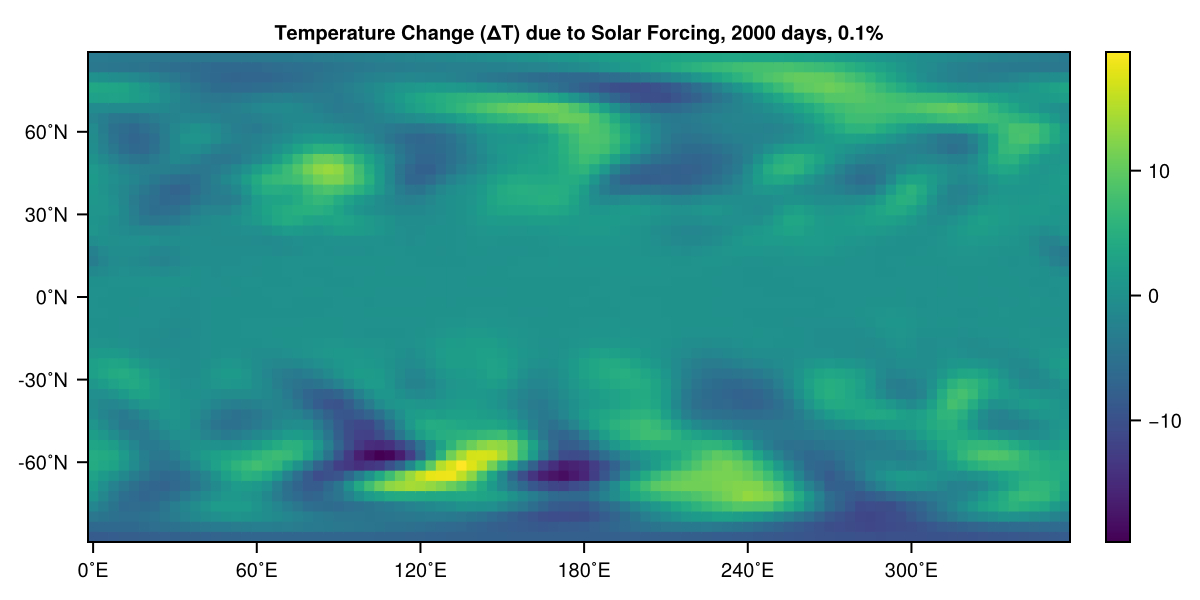

In [25]:
# Period = 2000 days
# Solar Forcing = 0.1%


spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(2000))   #change to 2000 days
#T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]
T1 = sim1.diagnostic_variables.grid.temp_grid[:,end]
T1_mean = mean(sim1.diagnostic_variables.grid.temp_grid, dims=3)

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(2000))   #change to 2000 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,end]
T2_mean = mean(sim2.diagnostic_variables.grid.temp_grid, dims=3)

println("Solar forcing simulation complete!")

ΔT = T2 - T1
ΔT_mean = T2_mean - T1_mean

println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))
println("Mean ΔT: ", mean(ΔT_mean))

heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing, 2000 days, 0.1%")
#savefig(pp, "deltaTL.png")


In [29]:
# Calculating climate sensitivity (lambda), 2000 days, 0.1% solar forcing

# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = fraction * S0

# mean ΔT from the simulation
delta_T_mean = 0.032805175  # value in Kelvin

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
println("ΔS (W/m²):", delta_S)
println("ΔT_mean (K):", delta_T_mean)
println("Climate sensitivity λ (K per W/m²):", lambda_climate)



ΔS (W/m²):1.361
ΔT_mean (K):0.032805175
Climate sensitivity λ (K per W/m²):0.024103728875826597


Extending the simulation period from 365 to 2000 days while maintaining a small solar forcing perturbation (0.1%) resulted in a decrease in the estimated climate sensitivity from λ ≈ 0.079 to λ ≈ 0.024. This reduction reflects the transition from an initial transient atmospheric response to a more equilibrated state of the climate system. Over longer timescales, energy redistribution through atmospheric circulation and heat uptake by the slab ocean reduces the net surface temperature response.

The slab ocean component plays a particularly important role by absorbing excess energy, thereby damping atmospheric warming. Consequently, the lower sensitivity obtained in the 2000-day simulation represents a more stable, quasi-equilibrium response of the simplified climate model. However, due to the model's simplified radiative processes and absence of fully coupled ocean dynamics, this value likely underestimates the true Earth system climate sensitivity.

 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:24:14 (2005-06-23, 325.44 years/day, 91 m/s, [-75, 28] ˚C)
 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:24:36 (2005-06-23, 320.54 years/day, 89 m/s, [-78, 29] ˚C)


Solar forcing simulation complete!
Max ΔT: 16.15857
Min ΔT: -18.087143
Mean ΔT: 0.10069062


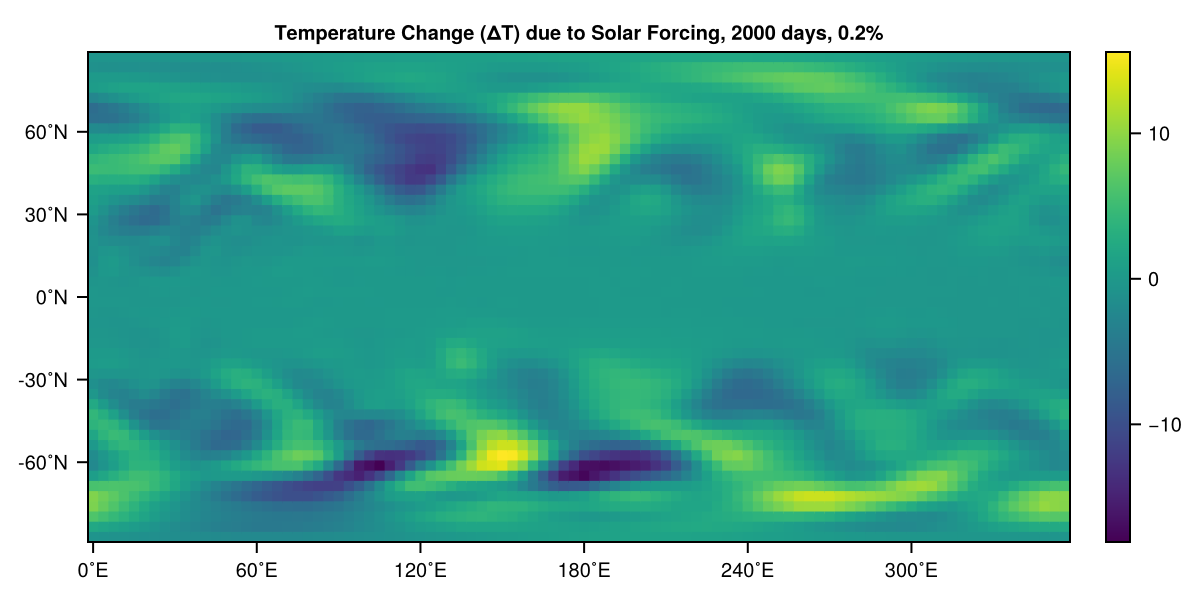

In [5]:
# Period = 2000 days
# Solar Forcing = 0.2%


spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(2000))   #change to 2000 days
#T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]
T1 = sim1.diagnostic_variables.grid.temp_grid[:,end]
T1_mean = mean(sim1.diagnostic_variables.grid.temp_grid, dims=3)

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.002)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(2000))   #change to 2000 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,end]
T2_mean = mean(sim2.diagnostic_variables.grid.temp_grid, dims=3)

println("Solar forcing simulation complete!")

ΔT = T2 - T1
ΔT_mean = T2_mean - T1_mean

println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))
println("Mean ΔT: ", mean(ΔT_mean))

heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing, 2000 days, 0.2%")



**The simulations were conducted using the PrimitiveWetModel in SpeedyWeather.jl, which solves the primitive equations for atmospheric dynamics and includes simplified representations of radiation, convection, and moisture processes. While this model captures the essential large-scale atmospheric response to solar forcing, it employs a slab ocean and simplified radiative transfer schemes, which limit its ability to fully represent long-term climate feedbacks. As a result, the estimated climate sensitivity (λ) is model-dependent response, lower than values obtained from more comprehensive Earth system models. Nevertheless, it provides a physically consistent first-order estimate of atmospheric sensitivity to solar forcing.**